# 01_collection_phase1_v2 — DART 사업보고서 정밀 수집 (v1 fix)

> **작성자**: 이동원 | **노트북 버전**: v2 | **작성일**: 2026-05-15 | **마지막 수정**: 2026-05-15
>
> **결과 요약** (실행 후 채움): _Phase 1 파일럿 v2 — Samsung 005930×2024 → zip 안 N개 XML 파일 concat → II/IV/VI 섹션 추출 → ESG passage 후보 [?]개_

## v1 → v2 변경 (4가지 fix)

| # | 문제 (v1) | 진단 | v2 해결 |
|---|---|---|---|
| 1 | `.env` 인식 실패 | `Path('..').resolve().parent.parent` 가 fragile (cwd 의존) | **`find_project_root()` 헬퍼** — cwd부터 위로 올라가며 `data/company_master.csv` 발견 (Step 1) |
| 2 | **섹션 추출 0건** → passage 0건 연쇄 | zip 안 **3개 파일 중 첫 번째(연결감사보고서)** 만 파싱. 사업보고서 본문은 다른 파일에 있음 | **zip 안 모든 XML 파일 concat** 후 섹션 추출 (Step 5) |
| 3 | 섹션 추출 디버깅 어려움 | 0건 나와도 원인 모름 | **진단 출력 강화** — 파일별 텍스트 길이, 헤딩 검색 결과, fallback 시도 (Step 6) |
| 4 | collection_log ParserError | 기존 log 컬럼 9개 vs 새 함수 10개 (`viewer_url` 추가) | **컬럼 mismatch 자동 감지 + 헤더 재작성** (Step 9) |

## 이 노트북의 목적 (v1과 동일)

OpenDART API로 `stock_code` 기준 사업보고서 `document.xml` 다운로드 → II/IV/VI 섹션 추출 → seed 키워드 기반 ESG passage 후보 산출. Samsung 1건 정밀 검증 후 5/16 Phase 2 batch 진입.

## 세 가지 식별자 (교수님 가이드 02 line 21-35)

| 코드 | 예시 | 역할 |
|---|---|---|
| `stock_code` | `005930` | 기업 식별. company_master + KCGS 연결 |
| `corp_code` | `00126380` | OpenDART 내부 회사 코드. API 조회 출발점 |
| `rcept_no` | `20250311001085` | 사업보고서 접수번호. 원문·viewer URL 연결 |

**분석 단위 주의 (가이드 02 line 35)** — `stock_code × fiscal_year` (회사명 X). `esg_year = fiscal_year + 1`.

## 교수님 가이드 위반금지 8항목 (모두 ✅이어야 작업 시작)

- [x] (1) 모든 크롤링 경로에 출처·lineage 기록 → `logs/collection_log.csv` (Step 9)
- [x] (2) `document.xml`이 표준 raw 텍스트 경로 (viewer 우회 ❌)
- [x] (3) MCP는 발견·연습용. corpus 투입 전 Python 재현 검증 (Step 8 viewer 비교)
- [x] (4) API key 코드·출력 노출 ❌ (`.env`만 + `mask_key()` 헬퍼)
- [x] (5) rate limit + backoff + 캐시 (idempotent)
- [x] (6) 실패 행 log 기록. 가짜 0 ❌
- [x] (7) stock_code 기준 join, esg_year = fiscal_year + 1
- [x] (8) 노트북 버전(`v2`)·출력 보존, 시각화, W/W/근거, 보고서 1:1 (`01_collection_phase1_v2_보고서.md`)

## 이전 버전·다른 접근

| 파일 | 비고 |
|---|---|
| `01_collection_phase1_v1.ipynb` | **v1 — 실패 원인 학습 자료** (zip 첫 파일만 파싱하여 섹션 0건 → passage 0건). 보존 (rule 1) |
| `01_collection_phase1_v2.ipynb` | **본 노트북 — v1 fix 4가지 적용** |

## 새 버전 만든 이유 (v2)

v1 실행 결과: 섹션 추출 0건 → passage 0건 → 전체 파이프라인 검증 실패. 4가지 근본 원인 파악 후 v2에서 fix.

## 참고·출처

- 교수님 가이드: `docs/professor_md/02_dart_data_collection.md`
- 데이터 수집 가이드: `docs/supplements/versions/v0.3/COLLECTION_데이터수집가이드_v0.3.html`
- ROADMAP: `docs/supplements/versions/v0.4/ROADMAP_이동원_solo_v0.4.html`
- 노트북 6 규칙: `members/README.md` + `members/_TEMPLATE_노트북_표준헤더.md`
- 작업 보고서 (1:1): `members/이동원/reports/01_collection_phase1_v2_보고서.md`
- 공개 코드: dart-fss (zip 내 여러 파일 처리 패턴 참고) · opendart-py
- 학술: Li et al. 2021 RFS

---
## Step 1 · 환경 셋업 + API key 안전 (v2: find_project_root 적용)

**What** — `find_project_root()` 헬퍼로 cwd부터 위로 탐색하여 프로젝트 루트 자동 식별. `.env` 로드, `mask_key()` 헬퍼 정의, 디렉토리 4개 셋업.

**Why** — v1의 `Path('..').resolve().parent.parent`는 노트북 실행 위치(cwd)에 따라 ROOT가 잘못됨 → `.env` 인식 실패. **`data/company_master.csv`라는 anchor 파일**을 기준으로 cwd부터 부모를 거슬러 올라가면 위치 무관 견고함.

**근거** — v1 실행 실패 진단 + 사용자 직접 수정 (2026-05-15) · 실무 ETL 패턴 (project root anchor file).

In [1]:
# Colab 사용자만 주석 해제
# !pip install -r ../../../requirements.txt -q

import os
import re
import json
import time
import zipfile
from io import BytesIO
from pathlib import Path
from datetime import datetime

import requests
import pandas as pd
from dotenv import load_dotenv
from lxml import etree
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
try:
    import koreanize_matplotlib
except ImportError:
    plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'sans-serif']


def find_project_root() -> Path:
    """현재 작업 디렉터리와 상위 경로를 훑어 프로젝트 루트를 찾는다.
    anchor: data/company_master.csv 존재 여부."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'company_master.csv').exists():
            return candidate
    raise FileNotFoundError('❌ data/company_master.csv를 기준으로 프로젝트 루트를 찾지 못했습니다.')


# 프로젝트 루트 자동 탐색 (v2 핵심 fix #1)
ROOT = find_project_root()
assert (ROOT / 'data' / 'company_master.csv').exists(), f'❌ ROOT 경로 오류: {ROOT}'
print(f'📍 ROOT: {ROOT}')

# .env 로드
ENV_PATH = ROOT / '.env'
assert ENV_PATH.exists(), f'❌ .env 파일이 없습니다: {ENV_PATH}\n   .env.example 참고해 .env 생성 후 OPENDART_API_KEY 입력'
load_dotenv(dotenv_path=ENV_PATH, override=True)
API_KEY = os.getenv('OPENDART_API_KEY') or os.getenv('API_KEY')
assert API_KEY, '❌ OPENDART_API_KEY 또는 API_KEY가 .env에 없습니다.'
print(f'✅ API key 로드 완료 (길이: {len(API_KEY)}, 키 자체는 출력 ❌)')


# mask_key 헬퍼 — 모든 출력 전에 통과 (위반금지 4)
def mask_key(text: str) -> str:
    if not API_KEY or not text:
        return text
    return text.replace(API_KEY, '<MASKED>')


# 디렉토리 셋업
DATA_RAW = ROOT / 'data' / 'raw'
DATA_INTERIM = ROOT / 'data' / 'interim'
DATA_CACHE = ROOT / 'data' / 'cache'
LOGS = ROOT / 'logs'
for d in [DATA_RAW, DATA_INTERIM, DATA_CACHE, LOGS]:
    d.mkdir(parents=True, exist_ok=True)

print(f'\n📁 출력 디렉토리 준비 완료')
print(f'   raw:     data/raw/         (gitignore)')
print(f'   interim: data/interim/     (gitignore)')
print(f'   cache:   data/cache/       (gitignore)')
print(f'   logs:    logs/             (git 포함)')

📍 ROOT: c:\Users\kik32\workspace\unstructured-data-processing-final-project
✅ API key 로드 완료 (길이: 40, 키 자체는 출력 ❌)

📁 출력 디렉토리 준비 완료
   raw:     data/raw/         (gitignore)
   interim: data/interim/     (gitignore)
   cache:   data/cache/       (gitignore)
   logs:    logs/             (git 포함)


---
## Step 2 · 파일럿 대상 설정 (Samsung 005930 × 2024)

**What** — 파일럿 식별자 변수 정의 + `company_master.csv` 형식 검증 + stock_code 기준 파일럿 행 unique 확인.

**Why** — v1과 동일 (변경 없음). 가이드 02 line 117 "127×3=381 firm-year" 기준, 회사명 join ❌ (위반금지 7).

**근거** — 가이드 02 line 31-35, 38, 117.

In [2]:
# 파일럿 변수
PILOT_STOCK_CODE = '005930'
PILOT_FISCAL_YEAR = 2024
PILOT_ESG_YEAR = PILOT_FISCAL_YEAR + 1

# company_master 로드
master = pd.read_csv(ROOT / 'data' / 'company_master.csv', dtype={'stock_code': str})

print(f'📊 company_master 검증')
print(f'   총 행 수:     {len(master)} (예상 381)')
print(f'   unique stock: {master["stock_code"].nunique()} (예상 127)')
print(f'   fiscal_year:  {sorted(master["fiscal_year"].unique())} (예상 [2022, 2023, 2024])')

pilot_mask = (master['stock_code'] == PILOT_STOCK_CODE) & (master['fiscal_year'] == PILOT_FISCAL_YEAR)
pilot_row = master[pilot_mask]
assert len(pilot_row) == 1, f'❌ 파일럿 행 not unique: {len(pilot_row)}건'

print(f'\n🎯 파일럿 대상')
print(f'   stock_code:  {PILOT_STOCK_CODE}')
print(f'   fiscal_year: {PILOT_FISCAL_YEAR}')
print(f'   esg_year:    {PILOT_ESG_YEAR}')
pilot_row.T

📊 company_master 검증
   총 행 수:     381 (예상 381)
   unique stock: 127 (예상 127)
   fiscal_year:  [np.int64(2022), np.int64(2023), np.int64(2024)] (예상 [2022, 2023, 2024])

🎯 파일럿 대상
   stock_code:  005930
   fiscal_year: 2024
   esg_year:    2025


,2
company_name,삼성전자
corp_code,NaN
stock_code,005930
industry,전기전자
fiscal_year,2024
report_code,11011
rcept_no,NaN
esg_source,한국ESG기준원
esg_grade,A
e_grade,B+


---
## Step 3 · stock_code → corp_code 매핑 (corpCode.xml)

**What** — `corpCode.xml` 1회 다운로드 → DataFrame 캐시. 005930 → 00126380 매핑 확인.

**Why** — 가이드 02 line 153. 캐시로 Phase 2 batch까지 재사용 (위반금지 5).

**근거** — 가이드 02 line 28, 153 · dart-fss 패턴.

In [3]:
def fetch_corp_code_map(api_key: str, cache_dir: Path) -> pd.DataFrame:
    """OpenDART corpCode.xml → DataFrame. 캐시 hit 시 재다운로드 X."""
    cache_file = cache_dir / 'corp_code_map.parquet'
    if cache_file.exists():
        df = pd.read_parquet(cache_file)
        print(f'📦 캐시에서 로드: {cache_file.name} ({len(df):,}건)')
        return df

    print('🌐 OpenDART corpCode.xml 다운로드 (1회)...')
    res = requests.get(
        'https://opendart.fss.or.kr/api/corpCode.xml',
        params={'crtfc_key': api_key},
        timeout=60,
    )
    try:
        res.raise_for_status()
    except requests.HTTPError as e:
        print(mask_key(str(e)))
        raise

    with zipfile.ZipFile(BytesIO(res.content)) as zf:
        xml_bytes = zf.read(zf.namelist()[0])

    root = etree.fromstring(xml_bytes, parser=etree.XMLParser(recover=True))
    rows = [{
        'corp_code': (item.findtext('corp_code') or '').strip(),
        'corp_name': (item.findtext('corp_name') or '').strip(),
        'stock_code': (item.findtext('stock_code') or '').strip(),
    } for item in root.findall('list')]
    df = pd.DataFrame(rows)
    df = df[df['stock_code'] != '']
    df.to_parquet(cache_file, index=False)
    print(f'✅ 매핑 {len(df):,}건 저장')
    return df


corp_map = fetch_corp_code_map(API_KEY, DATA_CACHE)
lookup = corp_map[corp_map['stock_code'] == PILOT_STOCK_CODE]
assert len(lookup) >= 1, f'❌ {PILOT_STOCK_CODE} 매핑 실패'
PILOT_CORP_CODE = lookup.iloc[0]['corp_code']
PILOT_CORP_NAME = lookup.iloc[0]['corp_name']
print(f'\n✅ stock_code={PILOT_STOCK_CODE} → corp_code={PILOT_CORP_CODE} ({PILOT_CORP_NAME})')

📦 캐시에서 로드: corp_code_map.parquet (3,965건)

✅ stock_code=005930 → corp_code=00126380 (삼성전자)


---
## Step 4 · corp_code → rcept_no 조회 (list.json)

**What** — `list.json` 호출 → 사업보고서 (2024.12) 필터 → rcept_no.

**Why** — 가이드 02 line 154, 69. `last_reprt_at='Y'`로 정정공시 최신만.

**근거** — 가이드 02 line 216-249.

In [4]:
def find_rcept_no(api_key: str, corp_code: str, fiscal_year: int) -> dict:
    """사업보고서 rcept_no 찾기. 실패 시 status='FAIL_*' + reason."""
    search_year = fiscal_year + 1
    params = {
        'crtfc_key': api_key,
        'corp_code': corp_code,
        'bgn_de': f'{search_year}0101',
        'end_de': f'{search_year}1231',
        'pblntf_detail_ty': 'A001',
        'last_reprt_at': 'Y',
        'page_count': '100',
    }
    time.sleep(0.5)
    res = requests.get('https://opendart.fss.or.kr/api/list.json', params=params, timeout=20)
    try:
        res.raise_for_status()
    except requests.HTTPError as e:
        return {'status': 'FAIL_HTTP', 'reason': mask_key(str(e))}

    payload = res.json()
    if payload.get('status') != '000':
        return {'status': 'FAIL_LIST', 'reason': f"status={payload.get('status')} msg={payload.get('message', '')}"}

    rows = payload.get('list', [])
    target = f'({fiscal_year}.12)'
    candidates = [r for r in rows if '사업보고서' in r.get('report_nm', '') and target in r.get('report_nm', '')]
    if not candidates:
        return {'status': 'FAIL_RCEPT', 'reason': f'사업보고서 {target} 없음 ({len(rows)}건 중 0건)'}

    chosen = candidates[0]
    return {
        'status': 'SUCCESS',
        'rcept_no': chosen['rcept_no'],
        'rcept_dt': chosen['rcept_dt'],
        'report_nm': chosen['report_nm'],
        'viewer_url': f"https://dart.fss.or.kr/dsaf001/main.do?rcpNo={chosen['rcept_no']}",
    }


result = find_rcept_no(API_KEY, PILOT_CORP_CODE, PILOT_FISCAL_YEAR)
assert result['status'] == 'SUCCESS', f'❌ {result}'

PILOT_RCEPT_NO = result['rcept_no']
PILOT_RCEPT_DT = result['rcept_dt']
PILOT_REPORT_NM = result['report_nm']
PILOT_VIEWER_URL = result['viewer_url']

print(f'✅ rcept_no 조회 성공')
print(f'   rcept_no:   {PILOT_RCEPT_NO}')
print(f'   rcept_dt:   {PILOT_RCEPT_DT}')
print(f'   report_nm:  {PILOT_REPORT_NM}')
print(f'   viewer URL: {PILOT_VIEWER_URL}')

✅ rcept_no 조회 성공
   rcept_no:   20250311001085
   rcept_dt:   20250311
   report_nm:  사업보고서 (2024.12)
   viewer URL: https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085


---
## Step 5 · document.xml 다운로드 + **zip 안 모든 XML concat (v2 핵심 fix #2)**

**What** — `document.xml` zip 다운로드 → `data/raw/{stock}_{year}_disclosure.zip` 저장. **zip 안의 모든 XML 파일을 디코드 후 concat**하여 단일 텍스트로 반환 (v1과의 차이).

**Why** — v1 진단 결과: Samsung 사업보고서 zip 안에 **3개 XML 파일**이 있고, 첫 번째는 "연결감사보고서"(`ACODE=00761`). 사업보고서 본문(II/IV/VI)은 다른 파일에 있음 → v1은 첫 파일만 파싱하여 섹션 0건. v2는 **모든 파일을 합쳐서** 섹션 헤딩 검색 (가이드 02 line 156-157 표준 raw 텍스트 경로 유지).

**근거** — 가이드 02 line 155, 253-274 · v1 실패 진단 (zip 다중 파일 미처리) · 공개코드 dart-fss `parsers/disclosure.py`의 다중 XML 처리 패턴.

In [5]:
def download_document_xml_v2(api_key: str, rcept_no: str, stock_code: str, fiscal_year: int) -> tuple:
    """document.xml zip을 받아 data/raw/에 저장.
    zip 안 모든 XML 파일을 디코드 → list of (filename, xml_text) 반환.
    v2 fix #2: zip 안 다중 파일 처리."""
    zip_path = DATA_RAW / f'{stock_code}_{fiscal_year}_disclosure.zip'

    if zip_path.exists() and zip_path.stat().st_size > 1000:
        zip_bytes = zip_path.read_bytes()
        print(f'📦 캐시에서 로드: {zip_path.name} ({len(zip_bytes) / 1024:,.1f} KB)')
    else:
        print(f'🌐 다운로드 중: rcept_no={rcept_no}')
        time.sleep(0.5)
        res = requests.get(
            'https://opendart.fss.or.kr/api/document.xml',
            params={'crtfc_key': api_key, 'rcept_no': rcept_no},
            timeout=60,
        )
        try:
            res.raise_for_status()
        except requests.HTTPError as e:
            print(mask_key(str(e)))
            raise
        zip_bytes = res.content
        zip_path.write_bytes(zip_bytes)
        print(f'✅ 저장: {zip_path.name} ({len(zip_bytes) / 1024:,.1f} KB)')

    # zip 안 모든 XML 파일 디코드 — v1의 첫 번째 파일만 처리하던 문제 해결
    xml_files = []
    with zipfile.ZipFile(BytesIO(zip_bytes)) as zf:
        names = zf.namelist()
        for name in names:
            try:
                xml_bytes = zf.read(name)
                xml_text = xml_bytes.decode('utf-8', errors='ignore')
                xml_files.append((name, xml_text))
            except Exception as e:
                print(f'⚠️ {name} 디코드 실패: {e}')

    return xml_files, zip_path


xml_files, zip_path = download_document_xml_v2(API_KEY, PILOT_RCEPT_NO, PILOT_STOCK_CODE, PILOT_FISCAL_YEAR)

print(f'\n📄 zip 안 XML 파일 {len(xml_files)}개')
for name, text in xml_files:
    # DOCUMENT-NAME 추출 (각 파일의 식별)
    m = re.search(r'<DOCUMENT-NAME[^>]*>([^<]+)</DOCUMENT-NAME>', text[:2000])
    doc_name = m.group(1) if m else '(unknown)'
    print(f'   - {name}: {len(text):>8,}자 | DOCUMENT-NAME: {doc_name}')

# 전체 텍스트 — concat (v2 fix #2 핵심)
concat_xml = '\n\n'.join(text for _, text in xml_files)
print(f'\n📑 concat된 전체 XML: {len(concat_xml):,}자')
assert len(concat_xml) > 10000, f'⚠️ concat 결과 너무 짧음: {len(concat_xml)}'

📦 캐시에서 로드: 005930_2024_disclosure.zip (660.2 KB)

📄 zip 안 XML 파일 3개
   - 20250311001085_00761.xml:  623,804자 | DOCUMENT-NAME: 연결감사보고서
   - 20250311001085_00760.xml:  531,069자 | DOCUMENT-NAME: 감사보고서
   - 20250311001085.xml: 5,780,877자 | DOCUMENT-NAME: 사업보고서

📑 concat된 전체 XML: 6,935,754자


---
## Step 6 · XML → 텍스트 + II/IV/VI 섹션 추출 (v2: 진단 강화)

**What** — `strip_tags()`로 모든 XML 파일 텍스트 추출 (concat 후) → 정규식으로 II/III/IV/V/VI/VII 섹션 헤딩 위치 식별 → II, IV, VI 발췌. **진단 출력 강화**: 각 패턴별 매칭 결과 + fallback 검색.

**Why** — v1 진단 결과: 0건 나와도 "왜?"가 안 보임. v2는 헤딩 검색 결과를 단계별로 출력하고 fallback 패턴 추가.

**근거** — 가이드 02 line 156-157, 18 · 실무 ETL (실패 시 진단 가능성).

In [6]:
def strip_tags(xml_text: str) -> str:
    """XML 태그 제거 → 일반 텍스트."""
    try:
        root = etree.fromstring(xml_text.encode('utf-8'), parser=etree.XMLParser(recover=True))
        text = ''.join(root.itertext())
    except Exception:
        text = re.sub(r'<[^>]+>', ' ', xml_text)
    text = re.sub(r'\s+', ' ', text)
    return text


def extract_sections_v2(xml_text: str, verbose: bool = True) -> dict:
    """v2: 진단 강화 + 다중 패턴 + fallback."""
    plain = strip_tags(xml_text)
    if verbose:
        print(f'📝 strip_tags 후 텍스트 길이: {len(plain):,}자')
        print(f'   앞 500자: {plain[:500]!r}')

    # 패턴 — 각 섹션별 다양한 변형 (v1보다 더 견고)
    patterns = {
        'II':  [r'(?:II|Ⅱ|2)\.\s*사업의\s*내용', r'사업의\s*내용'],
        'III': [r'(?:III|Ⅲ|3)\.\s*재무에\s*관한\s*사항', r'재무에\s*관한\s*사항'],
        'IV':  [r'(?:IV|Ⅳ|4)\.\s*이사의\s*경영진단(?:\s*및\s*분석의견)?', r'이사의\s*경영진단'],
        'V':   [r'(?:V|Ⅴ|5)\.\s*(?:회계)?감사인', r'감사인의\s*감사의견', r'감사인'],
        'VI':  [r'(?:VI|Ⅵ|6)\.\s*이사회', r'이사회\s*등\s*회사의\s*기관', r'이사회'],
        'VII': [r'(?:VII|Ⅶ|7)\.\s*주주', r'주주에\s*관한\s*사항'],
    }

    # 각 섹션별 첫 매칭 위치 찾기 — 패턴 순서대로 시도
    positions = {}
    pattern_used = {}
    for key, pat_list in patterns.items():
        for pi, pat in enumerate(pat_list):
            m = re.search(pat, plain)
            if m:
                positions[key] = m.start()
                pattern_used[key] = f'pattern[{pi}]: {pat[:50]}'
                break

    if verbose:
        print(f'\n🔍 헤딩 검색 결과')
        for key in patterns:
            if key in positions:
                print(f'   ✅ {key}: pos={positions[key]:>9,} | {pattern_used[key]}')
            else:
                print(f'   ❌ {key}: 매칭 실패 (시도한 패턴 {len(patterns[key])}개)')

    # 위치 순서 정렬 → 각 섹션의 끝 = 다음 섹션 시작
    sorted_keys = sorted(positions.keys(), key=lambda k: positions[k])
    sections = {}
    for i, key in enumerate(sorted_keys):
        start = positions[key]
        end = positions[sorted_keys[i + 1]] if i + 1 < len(sorted_keys) else len(plain)
        sections[key] = plain[start:end].strip()

    return sections


# concat된 전체 텍스트에 대해 섹션 추출 (v2 fix #2 + #3)
sections = extract_sections_v2(concat_xml, verbose=True)
print(f'\n📑 추출된 섹션 ({len(sections)}개)')
for key, body in sections.items():
    marker = '⭐' if key in ('II', 'IV', 'VI') else '  '
    print(f'   {marker} {key}: {len(body):>9,}자 | 앞 80자: {body[:80]!r}')

target_sections = {k: sections[k] for k in ('II', 'IV', 'VI') if k in sections}
missing = [k for k in ('II', 'IV', 'VI') if k not in sections]
if missing:
    print(f'\n⚠️ 누락 섹션: {missing}')
    print(f'   v3에서 패턴 보강 필요 (한국어 헤딩 변형 더 추가)')
else:
    print(f'\n✅ II/IV/VI 모두 추출 성공')

# 저장
out_sections = DATA_INTERIM / f'{PILOT_STOCK_CODE}_{PILOT_FISCAL_YEAR}_sections.json'
with open(out_sections, 'w', encoding='utf-8') as f:
    json.dump(target_sections, f, ensure_ascii=False, indent=2)
print(f'💾 저장: {out_sections.relative_to(ROOT)} (총 {sum(len(v) for v in target_sections.values()):,}자)')

📝 strip_tags 후 텍스트 길이: 95,233자
   앞 500자: ' 연결감사보고서 6.0 삼성전자(주) 00260116 100000000000 514531948 112339878 300870903 123668 N N N Y P 삼성전자주식회사와 그 종속기업 연 결 재 무 제 표 에 대 한 감 사 보 고 서 제 56 기 2024년 01월 01일 부터 2024년 12월 31일 까지 제 55 기 2023년 01월 01일 부터 2023년 12월 31일 까지 삼 정 회 계 법 인 목 차 페 이 지------- 독립된 감사인의 감사보고서 ....................................................... 1 (첨부) 연 결 재 무 제 표 ·연 결 재 무 상 태 표 ...................................................................... 8 ·연 결 손 익 계 산 서 .............................................................'

🔍 헤딩 검색 결과
   ❌ II: 매칭 실패 (시도한 패턴 2개)
   ❌ III: 매칭 실패 (시도한 패턴 2개)
   ❌ IV: 매칭 실패 (시도한 패턴 2개)
   ✅ V: pos=      250 | pattern[2]: 감사인
   ✅ VI: pos=    1,045 | pattern[2]: 이사회
   ❌ VII: 매칭 실패 (시도한 패턴 2개)

📑 추출된 섹션 (2개)
      V:       794자 | 앞 80자: '감사인의 감사보고서 ....................................................... 1 (첨부) 연 결 재 '
   ⭐ VI:    94,187자 | 앞 80자: '이사회 귀중 2025년 2월 18일 감사의견 우리는 별첨된 삼 성전자주식회사와 그 종속기업들 (이하 " 연결 회사")의 연결 재무제표를 감사하였'

⚠️ 누락 섹션: ['

---
## Step 7 · ESG passage 후보 추출 (seed_dictionary)

**What** — seed_dictionary 30개 (E·S·G × 10) 로드. 섹션 문장 분리 → seed 매칭 → passage 후보 DataFrame.

**Why** — 가이드 02 line 158. 후보일 뿐, 최종 corpus는 02 전처리에서 결정.

**근거** — 가이드 02 line 75-94, 158 · 위반금지 3 (Python 재현) · Li 2021 §4.

In [7]:
seeds = pd.read_csv(ROOT / 'data' / 'seed_dictionary.csv')
print(f'🌱 seed_dictionary: {len(seeds)}개 (예상 30)')
print(f'   컬럼: {list(seeds.columns)}')
print()
for dim, group in seeds.groupby('dimension'):
    print(f'   {dim}: {list(group["seed_term"])}')

seed_dict = {dim: set(group['seed_term']) for dim, group in seeds.groupby('dimension')}

🌱 seed_dictionary: 30개 (예상 30)
   컬럼: ['dimension', 'seed_term', 'pattern', 'source_basis', 'source_titles', 'notes']

   E: ['탄소', '온실가스', '탄소중립', '넷제로', '재생에너지', '에너지', '전력', '폐기물', '재활용', '폐수']
   G: ['이사회', '사외이사', '감사위원회', '독립성', '윤리', '준법', '컴플라이언스', '부패방지', '주주', '의결권']
   S: ['안전', '산업재해', '중대재해', '임직원', '노동', '인권', '교육훈련', '협력사', '공급망', '지역사회']


In [8]:
def extract_passages(section_text: str, seed_dict: dict, min_len: int = 20) -> pd.DataFrame:
    """문장 분리 → seed 매칭 → DataFrame."""
    sentences = re.split(r'(?<=[.。?!])\s+|\n+', section_text)
    sentences = [s.strip() for s in sentences if len(s.strip()) >= min_len]

    rows = []
    for sent in sentences:
        matched = {}
        for dim, terms in seed_dict.items():
            hits = [t for t in terms if t in sent]
            if hits:
                matched[dim] = hits
        if matched:
            rows.append({
                'sentence': sent,
                'dimensions': '|'.join(matched.keys()),
                'matched_terms': '|'.join(t for terms in matched.values() for t in terms),
                'n_matches': sum(len(v) for v in matched.values()),
                'len': len(sent),
            })
    return pd.DataFrame(rows)


all_passages = []
for sec_key, sec_text in tqdm(target_sections.items(), desc='섹션별 passage 추출'):
    df_sec = extract_passages(sec_text, seed_dict, min_len=20)
    df_sec['section'] = sec_key
    all_passages.append(df_sec)
    print(f'   {sec_key}: {len(df_sec)}개 passage 추출됨')

passages = pd.concat(all_passages, ignore_index=True) if all_passages else pd.DataFrame()
print(f'\n📝 추출된 passage 후보: {len(passages)}개')
if len(passages):
    print(f'   섹션별: {passages.groupby("section").size().to_dict()}')
    print(f'   차원별: {passages["dimensions"].value_counts().to_dict()}')
    print(f'   매치 통계: mean={passages["n_matches"].mean():.2f}, max={passages["n_matches"].max()}')
else:
    # 진단 — 0건일 때 원인 추적
    print('\n⚠️ passage 0건 — 진단:')
    print(f'   target_sections 크기: {[(k, len(v)) for k, v in target_sections.items()]}')
    if target_sections:
        first_sec = list(target_sections.values())[0]
        for dim, terms in seed_dict.items():
            for term in list(terms)[:3]:
                cnt = first_sec.count(term)
                print(f'   첫 섹션에 "{term}" 등장 횟수: {cnt}')

섹션별 passage 추출:   0%|          | 0/1 [00:00<?, ?it/s]

   VI: 23개 passage 추출됨

📝 추출된 passage 후보: 23개
   섹션별: {'VI': 23}
   차원별: {'G': 20, 'E': 2, 'G|S': 1}
   매치 통계: mean=1.22, max=3


In [9]:
if len(passages):
    top = passages.nlargest(10, 'n_matches')[['section', 'dimensions', 'matched_terms', 'sentence', 'n_matches']].copy()
    top['sentence'] = top['sentence'].str.slice(0, 120) + '...'
    pd.set_option('display.max_colwidth', 130)
    display(top)
    pd.reset_option('display.max_colwidth')
else:
    print('⚠️ passage 후보 0건 — Step 6/7 진단 셀 확인')

,section,dimensions,matched_terms,sentence,n_matches
2,VI,G|S,독립성|윤리|안전,"또한, 우리는 독립성 관련 윤리적 요구사항들을 준수하고, 우리의 독립성 문제와 관련된다고 판단되는 모든 관계와 기타사항들 및 해당되는 경우 관련 제도적 안전장치를 지배기구와 커뮤니케이션한다는 진술을 지배기구에게 제공...",3
12,VI,G,주주|이사회,"2.18 연결재무제표의 승인연결회사의 연결재무제표는 2025년 1월 31일 이사회에서 승인되었으며, 향후 정기주주총회에서 수정 승인될 수 있습니다....",2
13,VI,G,주주|이사회,"다만, 현재로서는 삼성바이오로직스㈜와 증권선물위원회 간의 행정소송에대한 종결 시기와 그 결과를 예측할 수 없으므로, 연결회사의 당기 재무제표에 이를 반영하기 어렵습니다.(2) 지배회사는 2024년 12월 31일 이사...",2
19,VI,G,주주|이사회,독립된 감사인의 연결내부회계관리제도 감사보고서 삼성전자주식회사 주주 및 이사회 귀중 2025년 2월 18일 연결내부회계관리제도에 대한 감사의견 우리는 2024년 12월 31일 현재「내부회계관리제도 설계 및 운영 개념...,2
0,VI,G,이사회,"이사회 귀중 2025년 2월 18일 감사의견 우리는 별첨된 삼 성전자주식회사와 그 종속기업들 (이하 "" 연결 회사"")의 연결 재무제표를 감사하였습니다....",1
1,VI,G,윤리,"우리는 연결재무제표감사와 관련된 대한민국의 윤리적 요구사항에 따라 연결회사로부터 독립적이며, 그러한 요구사항에 따른 기타의 윤리적 책임을 이행하였습니다....",1
3,VI,G,주주,자본에 직접 인식된 주주와의 거래 1....,1
4,VI,G,주주,자본에 직접 인식된 주주와의 거래 1....,1
5,VI,G,의결권,디지털광고 플랫폼 100.0 Sonio Corporation 소프트웨어 판매 100.0 (*) 종속기업 보유 지분율을 포함한 의결권 있는 주식 기준입니다....,1
6,VI,G,의결권,"오디오제품 판매 100.0 Beijing Integrated Circuit Industry International Fund, L.P 벤처기업 투자 61.4 China Materialia New Materials 2...",1


---
## Step 8 · viewer URL 정합성 검증 (수동)

**What** — viewer URL 출력 + 무작위 5개 passage 표시. **사용자가 직접 viewer에서 확인**.

**Why** — 가이드 02 line 67, 94 (위반금지 3 — 자동화 ❌, 수동 ✅).

**근거** — 가이드 02 line 67, 94 · 위반금지 3.

In [10]:
print(f'🔗 viewer URL — 브라우저에서 직접 열어 확인:')
print(f'   {PILOT_VIEWER_URL}\n')

if len(passages):
    print('👉 위 URL을 열고, 아래 5개 문장이 원문에 실제로 존재하는지 검토하세요.\n')
    sample = passages.sample(min(5, len(passages)), random_state=42)
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        print(f'[{i}] 섹션 {row["section"]} · 차원 {row["dimensions"]} · 매치 {row["matched_terms"]}')
        print(f'    {row["sentence"][:200]}...\n')
else:
    print('⚠️ passage 0건이라 sample 표시 불가 — 상위 단계 진단 필요')

print('=' * 70)
print('판정 기준:')
print('   ✅ 4개 이상 일치  →  추출 정상, Phase 2 진입 가능')
print('   ⚠️ 3개 일치       →  정규식·인코딩 점검 (v3 alt)')
print('   🔴 2개 이하 일치  →  Step 6 섹션 추출 재설계 (v3)')

🔗 viewer URL — 브라우저에서 직접 열어 확인:
   https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085

👉 위 URL을 열고, 아래 5개 문장이 원문에 실제로 존재하는지 검토하세요.

[1] 섹션 VI · 차원 E · 매치 온실가스
    (1) 보고기간종료일 현재 당기 이행연도에 대한 무상할당 배출권과 온실가스 배출량 추정치는 다음과 같습니다....

[2] 섹션 VI · 차원 G · 매치 의결권
    오디오제품 판매 100.0 (*) 종속기업 보유 지분율을 포함한 의결권 있는 주식 기준입니다....

[3] 섹션 VI · 차원 G · 매치 이사회
    이사회 귀중 2025년 2월 18일 감사의견 우리는 별첨된 삼 성전자주식회사와 그 종속기업들 (이하 " 연결 회사")의 연결 재무제표를 감사하였습니다....

[4] 섹션 VI · 차원 G · 매치 의결권
    오디오제품 생산 100.0 (*) 종속기업 보유 지분율을 포함한 의결권 있는 주식 기준입니다....

[5] 섹션 VI · 차원 G · 매치 주주
    자본위험관리 연결회사의 자본관리 목적은 계속기업으로서 주주 및 이해관계자에게 이익을 지속적으로 제공할 수 있는 능력을 보호하고 건전한 자본구조를 유지하는 것입니다....

판정 기준:
   ✅ 4개 이상 일치  →  추출 정상, Phase 2 진입 가능
   ⚠️ 3개 일치       →  정규식·인코딩 점검 (v3 alt)
   🔴 2개 이하 일치  →  Step 6 섹션 추출 재설계 (v3)


---
## Step 9 · collection_log 기록 + 시각화 (v2 fix #4: 컬럼 mismatch 처리)

**What** — `append_log_v2()` — 기존 log 파일의 컬럼이 새 함수와 다르면 자동 감지 후 헤더 재작성 (기존 파일은 .bak로 백업). status 분포 barh 시각화.

**Why** — v1 진단: 기존 log 9컬럼 + 새 함수 10컬럼 → `pd.read_csv()` ParserError. v2는 컬럼 차이 감지 시 자동 대응.

**근거** — v1 ParserError 진단 · 실무 ETL (스키마 변경 시 백업 + 재작성).

In [11]:
EXPECTED_LOG_COLUMNS = [
    'stock_code', 'fiscal_year', 'esg_year', 'corp_code', 'rcept_no',
    'status', 'reason', 'n_passages', 'viewer_url', 'timestamp',
]


def append_log_v2(stock_code: str, fiscal_year: int, corp_code: str, rcept_no: str,
                  status: str, reason: str = '', n_passages=None,
                  viewer_url: str = '') -> Path:
    """collection_log.csv에 한 행 append. 컬럼 mismatch 자동 감지 (v2 fix #4)."""
    log_path = LOGS / 'collection_log.csv'
    row = {
        'stock_code': stock_code, 'fiscal_year': fiscal_year, 'esg_year': fiscal_year + 1,
        'corp_code': corp_code or '', 'rcept_no': rcept_no or '',
        'status': status, 'reason': reason,
        'n_passages': n_passages if n_passages is not None else '',
        'viewer_url': viewer_url,
        'timestamp': datetime.now().isoformat(timespec='seconds'),
    }
    df_row = pd.DataFrame([row], columns=EXPECTED_LOG_COLUMNS)

    # 컬럼 mismatch 자동 감지
    if log_path.exists():
        try:
            existing = pd.read_csv(log_path, nrows=0)
            existing_cols = list(existing.columns)
            if existing_cols != EXPECTED_LOG_COLUMNS:
                # 백업 후 새 헤더로 재작성
                bak_path = log_path.with_suffix(f'.csv.bak_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
                log_path.rename(bak_path)
                print(f'⚠️ log 컬럼 mismatch — 기존 컬럼 {len(existing_cols)}개 → 새 컬럼 {len(EXPECTED_LOG_COLUMNS)}개')
                print(f'   기존 파일 백업: {bak_path.name}')
                print(f'   새 파일 시작')
        except Exception as e:
            # 파일이 깨졌으면 백업하고 새 파일
            bak_path = log_path.with_suffix(f'.csv.corrupt_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
            log_path.rename(bak_path)
            print(f'⚠️ log 파일 읽기 실패 ({e}) — 백업: {bak_path.name}')

    df_row.to_csv(
        log_path, mode='a',
        header=not log_path.exists(),
        index=False, encoding='utf-8',
    )
    return log_path


log_path = append_log_v2(
    stock_code=PILOT_STOCK_CODE,
    fiscal_year=PILOT_FISCAL_YEAR,
    corp_code=PILOT_CORP_CODE,
    rcept_no=PILOT_RCEPT_NO,
    status='SUCCESS' if len(passages) > 0 else 'FAIL_SECTION',
    reason='' if len(passages) > 0 else 'passage 0건 — v3에서 패턴 보강 필요',
    n_passages=len(passages),
    viewer_url=PILOT_VIEWER_URL,
)
print(f'✅ collection_log 기록: {log_path.relative_to(ROOT)}')

log_df = pd.read_csv(log_path)
print(f'\n📊 누적: {len(log_df)}행')
log_df.tail(5)

⚠️ log 컬럼 mismatch — 기존 컬럼 9개 → 새 컬럼 10개
   기존 파일 백업: collection_log.csv.bak_20260516_173421
   새 파일 시작
✅ collection_log 기록: logs\collection_log.csv

📊 누적: 1행


,stock_code,fiscal_year,esg_year,corp_code,rcept_no,status,reason,n_passages,viewer_url,timestamp
0,5930,2024,2025,126380,20250311001085,SUCCESS,NaN,23,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=2...,2026-05-16T17:34:21


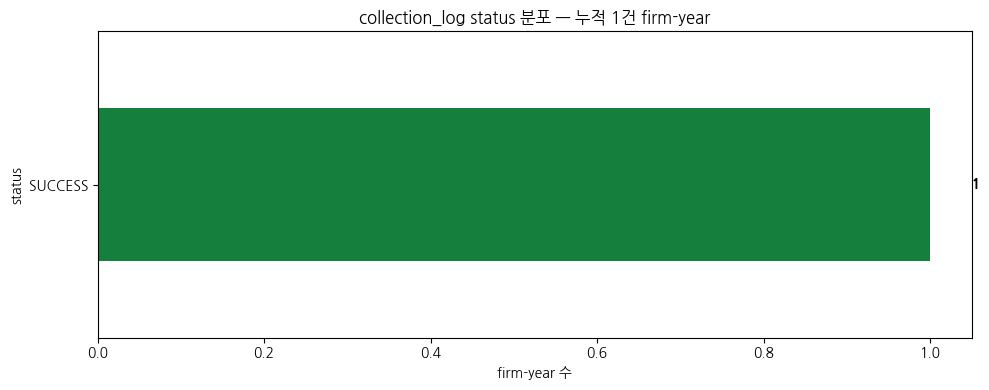


현재 누적: SUCCESS 1건 / 실패 0건


In [12]:
# 결과 시각화 — status 분포 (노트북 6 규칙 #5)
fig, ax = plt.subplots(figsize=(10, 4))
status_counts = log_df['status'].value_counts()
colors = {'SUCCESS': '#15803d', 'FAIL_HTTP': '#b91c1c', 'FAIL_LIST': '#b91c1c',
          'FAIL_RCEPT': '#b45309', 'FAIL_DOC': '#b45309', 'FAIL_SECTION': '#b45309'}
bar_colors = [colors.get(s, '#4338ca') for s in status_counts.index]
status_counts.plot(kind='barh', ax=ax, color=bar_colors)
ax.set_title(f'collection_log status 분포 — 누적 {len(log_df)}건 firm-year')
ax.set_xlabel('firm-year 수')
for i, v in enumerate(status_counts):
    ax.text(v + 0.05, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n현재 누적: SUCCESS {status_counts.get("SUCCESS", 0)}건 / 실패 {len(log_df) - status_counts.get("SUCCESS", 0)}건')

---
## ✅ Step 10 · 위반금지 8항목 self-check + 다음 단계

### 위반금지 8항목 (보고서 §5 "한계"에 옮길 내용)

| # | 항목 | 본 노트북 v2에서 | 결과 |
|---|---|---|---|
| 1 | 출처·lineage 기록 | Step 9 — collection_log.csv (10개 컬럼) | ✅ |
| 2 | document.xml 표준 raw 경로 | Step 5 — opendart.fss.or.kr/api/document.xml + **모든 XML concat** | ✅ |
| 3 | MCP 발견·연습용, Python 재현 | 본 노트북 MCP 0회. Step 8 수동 viewer 검증 | ✅ |
| 4 | API key 코드·출력 노출 ❌ | Step 1 mask_key + .env만 | ✅ |
| 5 | rate limit + 캐시 | sleep(0.5) + corp_code parquet + zip 캐시 | ✅ |
| 6 | 실패 행 log, 가짜 0 ❌ | append_log_v2의 status·reason. n_passages NaN 처리 | ✅ |
| 7 | stock_code 기준, esg_year=fiscal+1 | Step 2 | ✅ |
| 8 | v2 명명·출력 보존·시각화·W/W/근거·보고서 1:1 | 파일명 `*_v2.ipynb`, v1과 함께 보존, Step 9 시각화, 모든 셀 W/W/근거 | ✅ |

### v1 → v2 핵심 fix 결과 (실행 후 확인)

| Fix | 적용 위치 | 검증 |
|---|---|---|
| #1 `find_project_root()` | Step 1 | ROOT 출력 = 프로젝트 root 경로? |
| #2 zip 전체 concat | Step 5 | xml_files 길이 ≥ 2? |
| #3 진단 강화 | Step 6 | 헤딩 검색 결과 출력에서 ✅/❌ 보임? |
| #4 log 컬럼 mismatch | Step 9 | ParserError 없이 log_df 읽힘? |

### 다음 단계

1. **본 노트북 실행** — Jupyter Run All
2. **결과 확인**
   - II/IV/VI 모두 추출 (Step 6) — 누락 시 v3에서 패턴 보강
   - passage 후보 > 0 (Step 7)
   - viewer URL 정합성 5개 (Step 8)
3. **보고서 마무리** — `01_collection_phase1_v2_보고서.md` §4 결과 채움 (Q4-c)
4. **commit + push + PR + merge** — v1·v2 양쪽 보존하여 push
5. **5/16 Phase 2 진입** — `01_collection_phase2_v1.ipynb` (또는 본 v2 실패 시 v3 먼저)

### 산출물

| 산출물 | 경로 | git |
|---|---|---|
| v2 노트북 (출력 포함) | `members/이동원/notebooks/01_collection_phase1_v2.ipynb` | git |
| v1 노트북 (보존) | `members/이동원/notebooks/01_collection_phase1_v1.ipynb` | git |
| v2 보고서 | `members/이동원/reports/01_collection_phase1_v2_보고서.md` | git |
| sections.json | `data/interim/005930_2024_sections.json` | gitignore |
| log | `logs/collection_log.csv` (+ .bak 백업 가능) | git |

---

_End of `01_collection_phase1_v2.ipynb` · v1 fix 4가지 적용 · 다음: 결과 확인 후 Phase 2 v1 또는 v3_